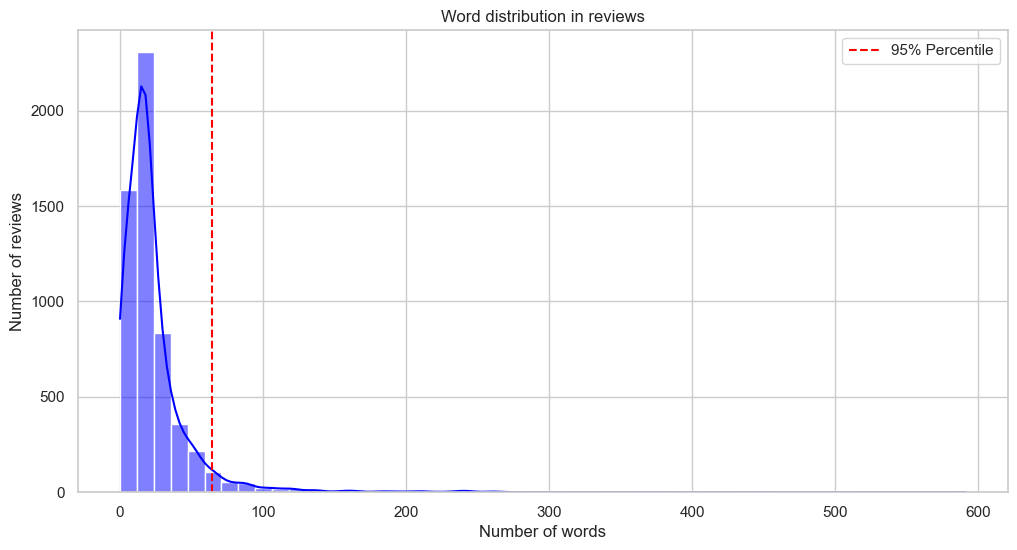

C:\Users\phant\AppData\Local\Temp\ipykernel_12144\2021663485.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=aspect_counts.values, y=aspect_counts.index, palette="viridis")


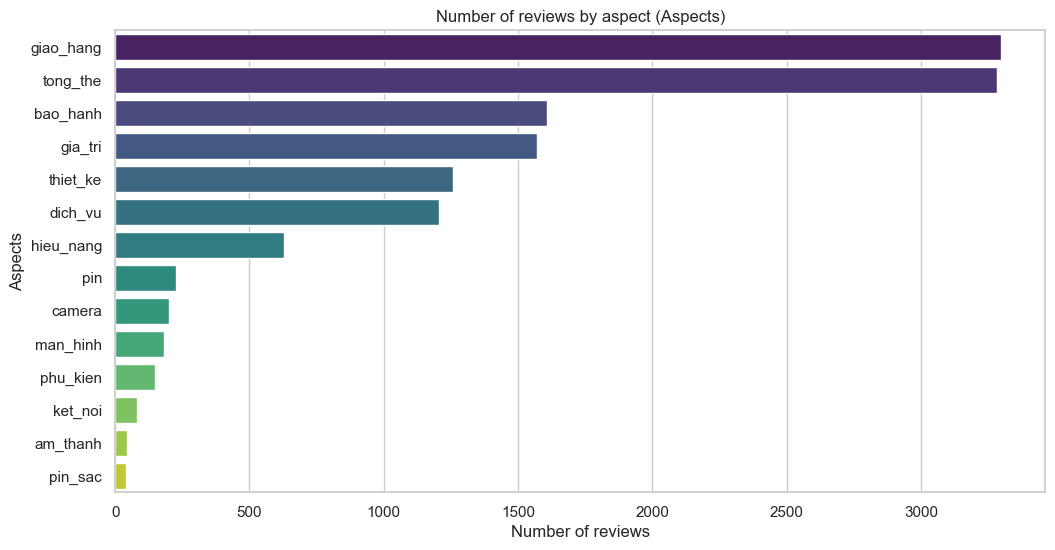

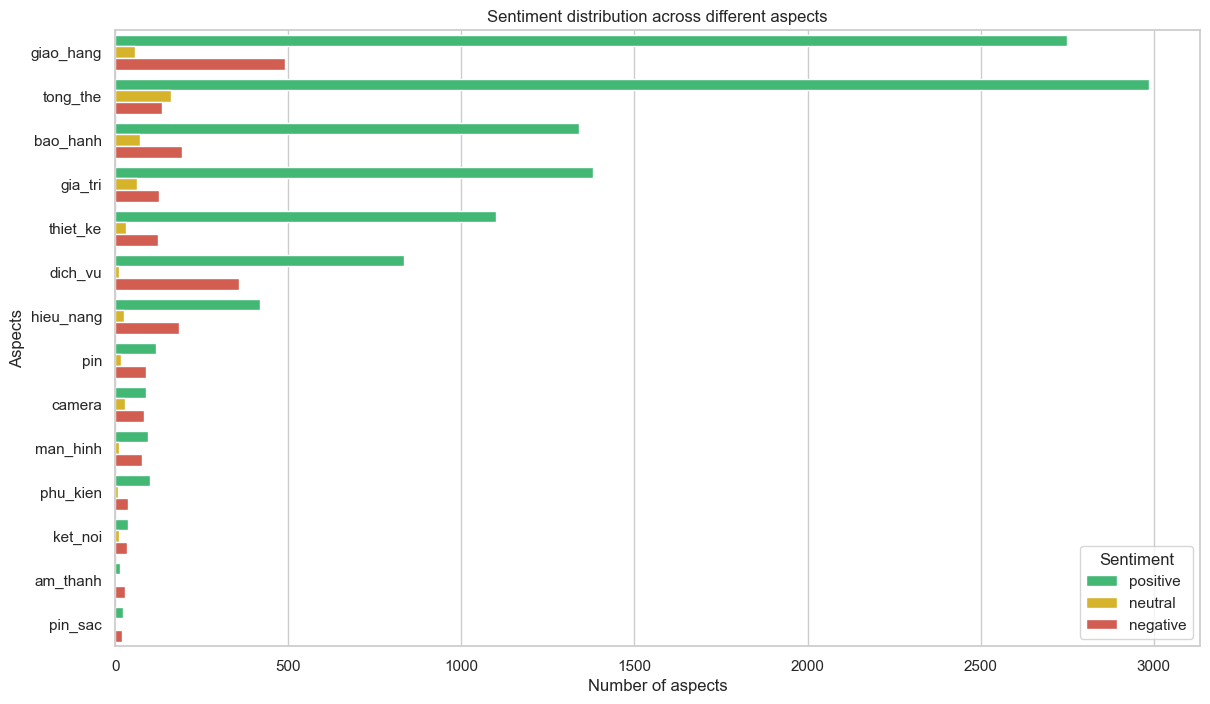


--- THỐNG KÊ CHIỀU DÀI OPINION PHRASE ---
count    13765.000000
mean         4.876571
std          3.341018
min          1.000000
25%          3.000000
50%          4.000000
75%          6.000000
max         53.000000
Name: opinion_len, dtype: float64


In [7]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD VÀ CHUYỂN ĐỔI DỮ LIỆU SANG DATAFRAME
# ==========================================
data_path = "../data/absa_results.jsonl"
raw_records = []

with open(data_path, 'r', encoding='utf-8') as f:
    for line in f:
        raw_records.append(json.loads(line))

df_main = pd.DataFrame(raw_records)

# Trải phẳng (flatten) mảng absa để dễ vẽ biểu đồ
absa_records = []
for idx, row in df_main.iterrows():
    for item in row.get('absa', []):
        absa_records.append({
            'review_id': row['review_id'],
            'rating_star': row['rating_star'],
            'aspect': item['aspect'],
            'sentiment': item['sentiment']
        })
        
df_absa = pd.DataFrame(absa_records)

# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ==========================================
# 2. EDA 1: PHÂN PHỐI CHIỀU DÀI CÂU
# ==========================================
plt.figure()
# Tính số từ bằng cách split khoảng trắng
df_main['word_count'] = df_main['comment_clean'].apply(lambda x: len(str(x).split()))

sns.histplot(df_main['word_count'], bins=50, kde=True, color='blue')
plt.title('Word distribution in reviews')
plt.xlabel('Number of words')
plt.ylabel('Number of reviews')
plt.axvline(df_main['word_count'].quantile(0.95), color='red', linestyle='--', label='95% Percentile')
plt.legend()
plt.show()
# -> Nhìn vào đường màu đỏ (95%), bạn sẽ biết nên set MAX_LEN là bao nhiêu.

# ==========================================
# 3. EDA 2: TẦN SUẤT XUẤT HIỆN CỦA CÁC KHÍA CẠNH
# ==========================================
plt.figure()
aspect_counts = df_absa['aspect'].value_counts()
sns.barplot(x=aspect_counts.values, y=aspect_counts.index, palette="viridis")
plt.title('Number of reviews by aspect (Aspects)')
plt.xlabel('Number of reviews')
plt.ylabel('Aspects')
plt.show()

# ==========================================
# 4. EDA 3: PHÂN PHỐI CẢM XÚC TRONG TỪNG KHÍA CẠNH
# ==========================================
plt.figure(figsize=(14, 8))
sns.countplot(data=df_absa, y='aspect', hue='sentiment', 
              order=df_absa['aspect'].value_counts().index,
              palette={'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#f1c40f'})
plt.title('Sentiment distribution across different aspects')
plt.xlabel('Number of aspects')
plt.ylabel('Aspects')
plt.legend(title='Sentiment')
plt.show()
# -> Biểu đồ này cực kỳ quan trọng để bạn thấy nhãn nào đang là "thiểu số" (rare classes).

# ==========================================
# 5. EDA 4: ĐÁNH GIÁ ĐỘ DÀI TRUNG BÌNH CỦA OPINION PHRASE (Tùy chọn)
# ==========================================
# Xem người dùng thường dùng bao nhiêu từ để mô tả 1 khía cạnh
df_absa['opinion_len'] = [len(str(item['opinion_phrase']).split()) 
                          for row in df_main['absa'] for item in row]

print("\n--- THỐNG KÊ CHIỀU DÀI OPINION PHRASE ---")
print(df_absa['opinion_len'].describe())